# Connect 4 bot: depth vs. strength analysis

This notebook only **reads** the result files in `experiments/results/` (produced by the experiment
scripts) and draws every chart into `experiments/figures/`. Re-run the scripts first if you want fresh
numbers (see the README, "Reproduce the experiments"). The plotting code lives in `experiments/plots.py`
so the same figures can be regenerated headless with `python experiments/plots.py`.

In [1]:
import json, os, sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

HERE = os.path.abspath(".")
if os.path.basename(HERE) != "experiments":          # allow running from the repo root too
    HERE = os.path.join(HERE, "experiments")
sys.path.insert(0, HERE)
import plots
plots.style()
R = lambda name: os.path.join(plots.RESULTS, name)
pd.set_option("display.width", 140)

## 1. Round-robin tournament (depths 1-8)

50 random openings of 2-4 plies, each played twice with colours swapped, so 100 games per pairing,
28 pairings. Score = wins + 0.5 x draws.

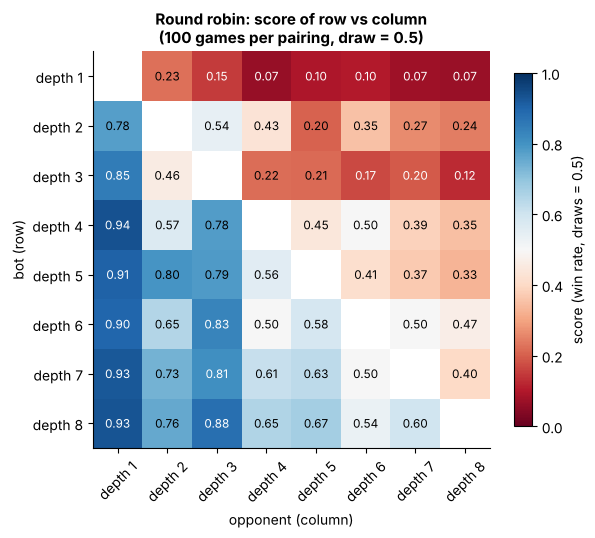

games: 2800  draws: 8.4%  mean length: 28.0 plies
first player (P1 colour) score: 0.494


In [2]:
path, fig = plots.winrate_heatmap(); plt.show()
games = pd.read_csv(R("results.csv"))
d = games[games.experiment == "depth"]
print("games:", len(d), " draws: %.1f%%" % (100 * (d.winner == "draw").mean()),
      " mean length: %.1f plies" % d.plies.mean())
print("first player (P1 colour) score: %.3f" % ((d.winner == d["first"]).mean() + 0.5 * (d.winner == "draw").mean()))

### Elo (maximum-likelihood Bradley-Terry, depth 1 = 1000, 95% cluster-bootstrap CI over openings)

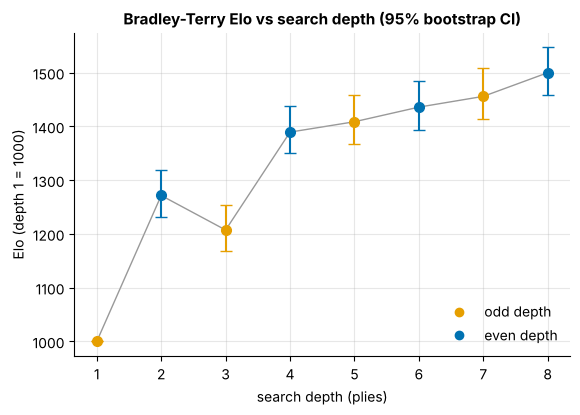

,elo,lo,hi
d1,1000.0,1000.0,1000.0
d2,1271.5,1230.6,1318.6
d3,1207.3,1167.9,1253.9
d4,1389.4,1350.1,1437.3
d5,1408.7,1366.7,1457.6
d6,1435.9,1394.0,1483.7
d7,1455.9,1413.2,1508.1
d8,1499.9,1458.9,1547.0


,gain,lo,hi
d1->d2,271.5,230.6,318.6
d2->d3,-64.2,-97.5,-30.0
d3->d4,182.1,150.9,216.6
d4->d5,19.3,-11.3,51.7
d5->d6,27.3,-5.6,56.1
d6->d7,19.9,-10.9,54.6
d7->d8,44.1,9.3,77.1


In [3]:
path, fig = plots.elo_plot(); plt.show()
elo = json.load(open(R("elo.json")))
display(pd.DataFrame(elo["ratings"]).T)
display(pd.DataFrame(elo["step_gain"]).T)

### Adjacent depths: deeper vs shallower (Wilson CI on score, exact binomial test on decisive games)

In [4]:
display(pd.read_csv(R("tournament_adjacent.csv")))

,deeper,shallower,games,wins,draws,losses,score,ci_lo,ci_hi,binom_p
0,d2,d1,100,77,1,22,0.775,0.6839,0.8458,2.490000e-08
1,d3,d2,100,43,6,51,0.460,0.3656,0.5574,4.700000e-01
2,d4,d3,100,72,12,16,0.780,0.6893,0.8500,1.190000e-09
3,d5,d4,100,51,9,40,0.555,0.4574,0.6486,2.940000e-01
4,d6,d5,100,50,17,33,0.585,0.4870,0.6767,7.840000e-02
5,d7,d6,100,40,20,40,0.500,0.4038,0.5962,1.000000e+00
6,d8,d7,100,47,26,27,0.600,0.5020,0.6906,2.650000e-02


## 2. Difficulty slider (statement section 5, "Slider works")

Every level plays RandomAgent and the next level up. Levels 4-9 are exactly depths 3-8, so their
games against each other are the tournament games. Games involving level 10 (iterative deepening with a
1.9 s limit) use 25 openings (50 games) to bound the run time.

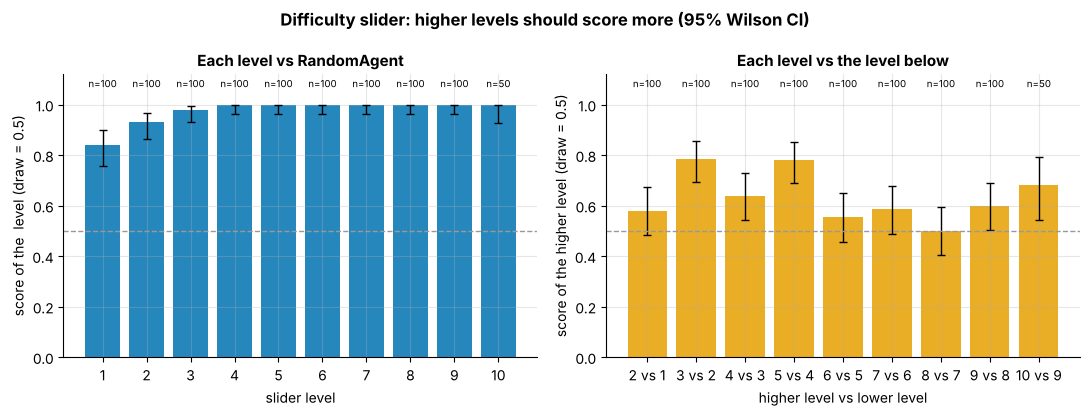

,level,opponent,games,wins,draws,losses,score,ci_lo,ci_hi,binom_p,mean_ms,max_ms,mean_plies
0,L1,random,100,84,0,16,0.840,0.7558,0.8990,2.610000e-12,0.1,3.1,16.7
1,L2,random,100,93,0,7,0.930,0.8625,0.9657,2.730000e-20,0.1,5.1,12.9
2,L3,random,100,98,0,2,0.980,0.9300,0.9945,7.970000e-27,0.2,4.3,13.5
3,L4,random,100,100,0,0,1.000,0.9630,1.0000,1.580000e-30,0.8,6.4,12.6
4,L5,random,100,100,0,0,1.000,0.9630,1.0000,1.580000e-30,1.9,9.2,12.8
5,L6,random,100,100,0,0,1.000,0.9630,1.0000,1.580000e-30,5.7,29.9,12.6
6,L7,random,100,100,0,0,1.000,0.9630,1.0000,1.580000e-30,12.2,54.7,12.7
7,L8,random,100,100,0,0,1.000,0.9630,1.0000,1.580000e-30,27.6,133.9,13.4
8,L9,random,100,100,0,0,1.000,0.9630,1.0000,1.580000e-30,54.4,327.7,12.9
9,L10,random,50,50,0,0,1.000,0.9286,1.0000,1.780000e-15,1258.8,1918.4,12.5


In [5]:
path, fig = plots.slider_plot(); plt.show()
display(pd.read_csv(R("slider_summary.csv")))

### Responsiveness: ms per move by level (single process, fixed test positions)

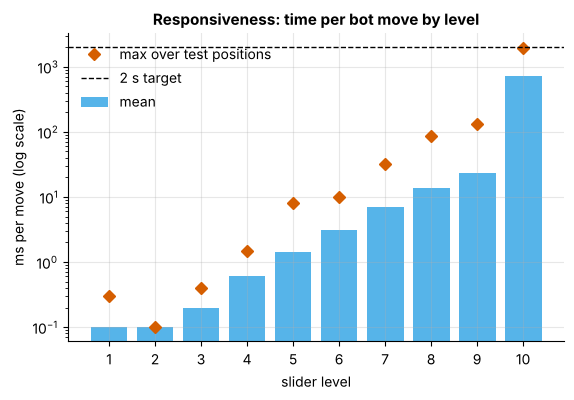

,level,n,mean_ms,median_ms,p95_ms,max_ms,mean_depth_reached,under_2s
0,1,54,0.1,0.1,0.1,0.3,1.00,1
1,2,54,0.1,0.1,0.1,0.1,1.00,1
2,3,54,0.2,0.2,0.4,0.4,1.78,1
3,4,54,0.6,0.7,1.2,1.5,2.52,1
4,5,54,1.4,1.2,3.3,8.1,3.15,1
5,6,54,3.1,2.3,9.2,9.8,3.76,1
6,7,54,7.0,4.1,24.4,31.9,4.37,1
7,8,54,13.8,5.2,52.1,86.3,4.98,1
8,9,54,23.0,9.1,71.0,133.1,5.59,1
9,10,54,725.7,74.2,1914.7,1920.2,9.19,1


In [6]:
if os.path.exists(R("responsiveness.csv")):
    path, fig = plots.responsiveness_plot(); plt.show()
    display(pd.read_csv(R("responsiveness.csv")))

## 3. Accuracy against perfect play

3,000 positions labeled with Pascal Pons' solver (`data/accuracy_positions.csv`). *Optimal* = the bot's
column is one of the solver's best columns. *Keeps the result* = the move does not turn a win into a
draw/loss or a draw into a loss (computed on positions that are not already lost, where it is
informative). Dashed lines are the same metrics for a uniformly random move. Error bars: 95% Wilson
intervals; consecutive depths are compared with paired exact McNemar tests on the same positions.

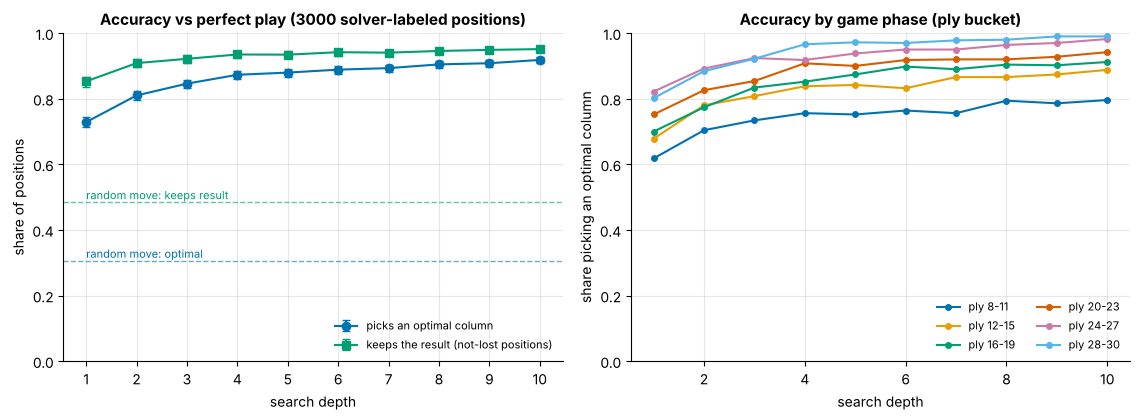

,depth,n,optimal,opt_lo,opt_hi,keeps_nl,keeps_nl_lo,keeps_nl_hi,rand_optimal,rand_keeps_nl,mean_ms
0,1,3000,0.7287,0.7125,0.7443,0.8529,0.8372,0.8673,0.3052,0.484,0.087
7,2,3000,0.8100,0.7956,0.8236,0.9086,0.8957,0.9201,0.3052,0.484,0.199
14,3,3000,0.8460,0.8326,0.8585,0.9217,0.9096,0.9324,0.3052,0.484,0.565
21,4,3000,0.8730,0.8606,0.8844,0.9349,0.9236,0.9446,0.3052,0.484,1.283
28,5,3000,0.8797,0.8675,0.8908,0.9344,0.9231,0.9441,0.3052,0.484,2.813
35,6,3000,0.8887,0.8769,0.8994,0.9419,0.9312,0.9510,0.3052,0.484,5.407
42,7,3000,0.8933,0.8818,0.9039,0.9405,0.9296,0.9498,0.3052,0.484,10.816
49,8,3000,0.9047,0.8936,0.9147,0.9456,0.9352,0.9545,0.3052,0.484,19.266
56,9,3000,0.9083,0.8975,0.9181,0.9489,0.9387,0.9575,0.3052,0.484,36.324
63,10,3000,0.9183,0.9080,0.9276,0.9513,0.9413,0.9596,0.3052,0.484,62.129


depth,1,2,3,4,5,6,7,8,9,10
bucket,,,,,,,,,,
12-15,0.6780,0.780,0.808,0.838,0.8420,0.8320,0.8660,0.8660,0.8740,0.8880
16-19,0.7000,0.774,0.834,0.852,0.8740,0.8980,0.8900,0.9040,0.9020,0.9120
20-23,0.7520,0.826,0.854,0.908,0.9000,0.9180,0.9200,0.9200,0.9280,0.9420
24-27,0.8220,0.892,0.924,0.918,0.9380,0.9500,0.9500,0.9640,0.9700,0.9820
28-30,0.8020,0.884,0.922,0.966,0.9720,0.9700,0.9780,0.9800,0.9900,0.9900
8-11,0.6180,0.704,0.734,0.756,0.7520,0.7640,0.7560,0.7940,0.7860,0.7960
all,0.7287,0.810,0.846,0.873,0.8797,0.8887,0.8933,0.9047,0.9083,0.9183


paired McNemar tests, depth d vs d+1:


,from,to,metric,n,only_shallower,only_deeper,delta,mcnemar_p
0,1,2,optimal,3000,96,340,0.0813,4.710000e-33
1,1,2,keeps,3000,30,149,0.0397,3.600000e-20
2,2,3,optimal,3000,114,222,0.0360,3.930000e-09
3,2,3,keeps,3000,46,74,0.0093,1.340000e-02
4,3,4,optimal,3000,90,171,0.0270,6.030000e-07
5,3,4,keeps,3000,35,63,0.0093,6.090000e-03
6,4,5,optimal,3000,95,115,0.0067,1.900000e-01
7,4,5,keeps,3000,45,44,-0.0003,1.000000e+00
8,5,6,optimal,3000,77,104,0.0090,5.300000e-02
9,5,6,keeps,3000,36,52,0.0053,1.090000e-01


In [7]:
path, fig = plots.accuracy_plot(); plt.show()
acc = pd.read_csv(R("accuracy_accuracy_summary.csv"))
display(acc[acc.bucket == "all"][["depth", "n", "optimal", "opt_lo", "opt_hi", "keeps_nl",
                                  "keeps_nl_lo", "keeps_nl_hi", "rand_optimal", "rand_keeps_nl", "mean_ms"]])
display(acc.pivot(index="bucket", columns="depth", values="optimal"))
print("paired McNemar tests, depth d vs d+1:")
display(pd.read_csv(R("accuracy_accuracy_tests.csv")))
if os.path.exists(R("accuracy_accuracy_subset_summary.csv")):
    sb = pd.read_csv(R("accuracy_accuracy_subset_summary.csv"))
    display(sb[sb.bucket == "all"][["depth", "n", "optimal", "opt_lo", "opt_hi", "keeps_nl", "mean_ms"]])

### Breakdowns: unique vs several optimal columns, outcome of the position, and how often the search proves the result early

In [8]:
m = pd.read_csv(R("accuracy_accuracy_moves.csv"))
pos = pd.read_csv(os.path.join(plots.DATA, "accuracy_positions.csv"))
pos["unique_optimal"] = pos.optimal_cols.apply(lambda s: len(json.loads(s)) == 1)
m = m.merge(pos[["moves", "unique_optimal"]], on="moves")
display(m.groupby(["depth", "unique_optimal"]).optimal.mean().unstack().round(3))
display(m.groupby(["depth", "outcome"]).optimal.mean().unstack().round(3))
display(m.groupby("depth").apply(lambda g: (g.depth_reached < g.name).mean()).rename("share proven before full depth").round(3))

unique_optimal,False,True
depth,,
1,0.785,0.698
2,0.847,0.789
3,0.866,0.835
4,0.880,0.869
5,0.890,0.874
6,0.893,0.886
7,0.900,0.890
8,0.912,0.900
9,0.913,0.906


outcome,draw,loss,win
depth,,,
1,0.641,0.649,0.776
2,0.782,0.820,0.809
3,0.808,0.819,0.863
4,0.829,0.865,0.882
5,0.846,0.871,0.888
6,0.846,0.883,0.896
7,0.868,0.882,0.902
8,0.863,0.911,0.907
9,0.880,0.905,0.913


depth
1     0.000
2     0.253
3     0.305
4     0.381
5     0.405
6     0.434
7     0.449
8     0.467
9     0.480
10    0.505
Name: share proven before full depth, dtype: float64

## 4. Tactics suite

52 solver-verified positions (`experiments/tactics_positions.json`): 13 each of win in 1, must block,
win in 2 (3 plies) and win in 3 (5 plies). Success criterion: at depth >= 2 the bot always takes a
win in 1 and always blocks.

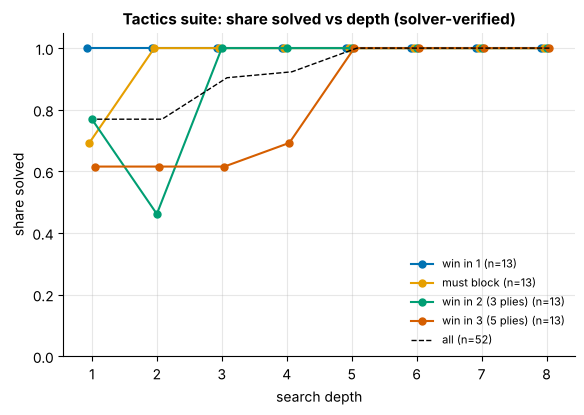

category,win1,block,win2,win3,all
agent,,,,,
d1,1.0000,0.6923,0.7692,0.6154,0.7692
d2,1.0000,1.0000,0.4615,0.6154,0.7692
d3,1.0000,1.0000,1.0000,0.6154,0.9038
d4,1.0000,1.0000,1.0000,0.6923,0.9231
d5,1.0000,1.0000,1.0000,1.0000,1.0000
d6,1.0000,1.0000,1.0000,1.0000,1.0000
d7,1.0000,1.0000,1.0000,1.0000,1.0000
d8,1.0000,1.0000,1.0000,1.0000,1.0000
L1,0.6245,0.4415,0.5084,0.4212,0.4989


In [9]:
path, fig = plots.tactics_plot(); plt.show()
t = pd.read_csv(R("tactics_summary.csv"))
display(t.pivot(index="agent", columns="category", values="share_solved")
         .loc[["d%d" % i for i in range(1, 9)] + ["L1", "L2", "L3"], ["win1", "block", "win2", "win3", "all"]])

## 5. Cost of strength

Nodes and milliseconds per move on fixed positions (6 openings + 8 per ply bucket of the accuracy set),
for the shipped search and three ablations. The chart uses the positions the search does not solve by
depth 10 (on solved ones it stops early, which hides the exponential growth). Every configuration returns the same move and score; only
the work differs. Points are drawn only for depths at which every position finished under the time cap.

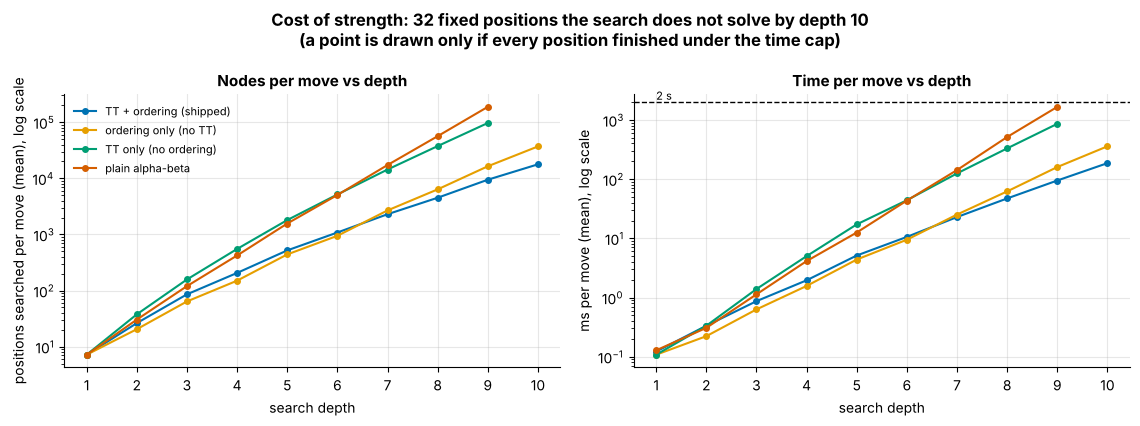

open positions: 32   (all positions: 54 )


config,full,no_order,no_tt,plain
depth,,,,
1,7.0,7.0,7.0,7.0
2,26.0,38.0,20.0,30.0
3,86.0,158.0,64.0,120.0
4,206.0,551.0,150.0,422.0
5,520.0,1803.0,440.0,1564.0
6,1083.0,5152.0,945.0,5047.0
7,2292.0,14330.0,2678.0,17240.0
8,4508.0,37497.0,6353.0,56286.0
9,9436.0,96657.0,16375.0,187482.0


config,full,no_order,no_tt,plain
depth,,,,
1,0.1,0.1,0.1,0.1
2,0.3,0.3,0.2,0.3
3,0.9,1.4,0.6,1.1
4,2.0,5.0,1.6,4.1
5,5.1,17.2,4.4,12.5
6,10.6,44.0,9.5,43.4
7,22.9,124.9,25.2,142.4
8,47.2,331.0,62.1,514.9
9,94.8,860.5,160.0,1663.8


shipped search, ALL positions (proven positions stop early):


,depth,mean_nodes,mean_ms,max_ms,proven_early,mean_depth_reached
0,1,5.9,0.097,0.514,0,1.00
1,2,20.5,0.244,1.965,12,1.78
2,3,62.4,0.614,2.496,14,2.52
3,4,136.5,1.285,4.355,20,3.15
4,5,326.6,3.204,12.908,21,3.76
5,6,664.5,6.456,29.783,21,4.37
6,7,1390.7,13.835,67.596,21,4.98
7,8,2712.2,28.319,199.985,21,5.59
8,9,5648.1,56.649,346.320,21,6.20
9,10,10571.7,110.855,845.335,22,6.80


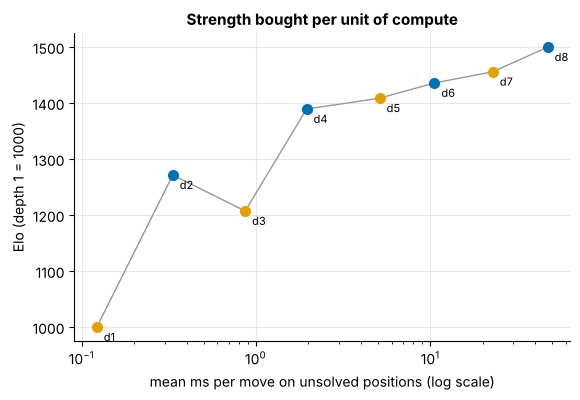

In [10]:
path, fig = plots.cost_plot(); plt.show()
c_all = pd.read_csv(R("cost_summary.csv"))
c = c_all[c_all.subset == "open"]      # positions not solved by depth 10: full-depth searches
print("open positions:", c.n.max(), "  (all positions:", c_all[c_all.subset == "all"].n.max(), ")")
display(c.pivot(index="depth", columns="config", values="mean_nodes").round(0))
display(c.pivot(index="depth", columns="config", values="mean_ms").round(1))
print("shipped search, ALL positions (proven positions stop early):")
display(c_all[(c_all.subset == "all") & (c_all.config == "full")][["depth", "mean_nodes", "mean_ms", "max_ms", "proven_early", "mean_depth_reached"]])
path, fig = plots.strength_vs_cost_plot(); plt.show()

## 6. Odd vs even depth (horizon effect)

At odd depths the bot's own move is the last one searched (optimistic static evaluation), at even
depths the opponent's (pessimistic).

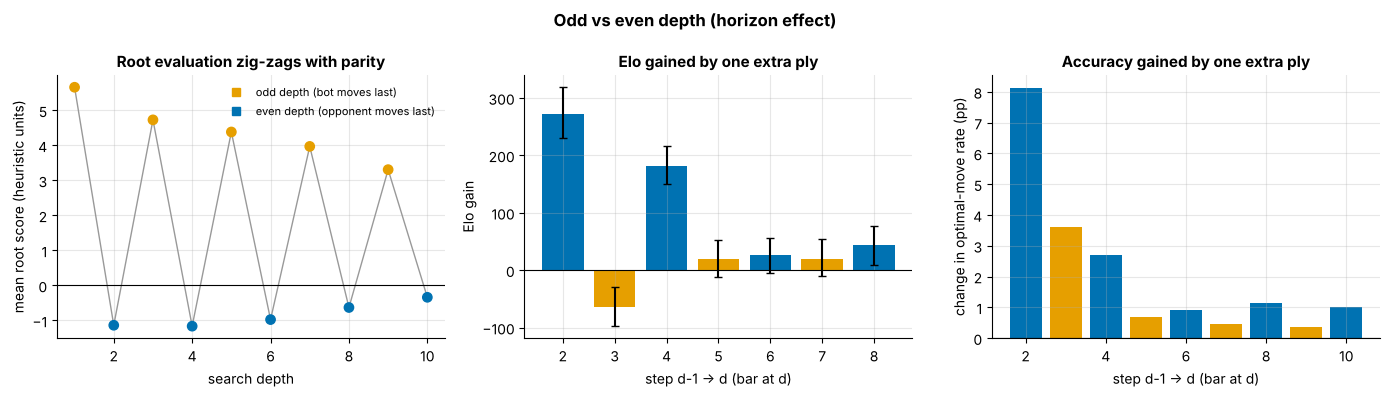

{
 "strength_step_odd_mean_elo_gain": -8.3333,
 "strength_step_even_mean_elo_gain": 131.25,
 "accuracy_step_odd_mean_delta_optimal": 0.0127,
 "accuracy_step_even_mean_delta_optimal": 0.0277
}


In [11]:
path, fig = plots.oddeven_plot(); plt.show()
print(json.dumps(json.load(open(R("oddeven.json"))).get("parity_means", {}), indent=1))

## 7. Embedding-neighbor artifact

Query = the position after `44334552`, then one controlled change (add the engine's move). Top-5
cosine neighbors from the self-play corpus under the hand-crafted feature embedding and the raw
42-cell baseline. The second table measures "similarity != same best move" on the 3,000 solver-labeled
positions (leave-one-out top-5 neighbors vs random pairs from the same ply bucket).

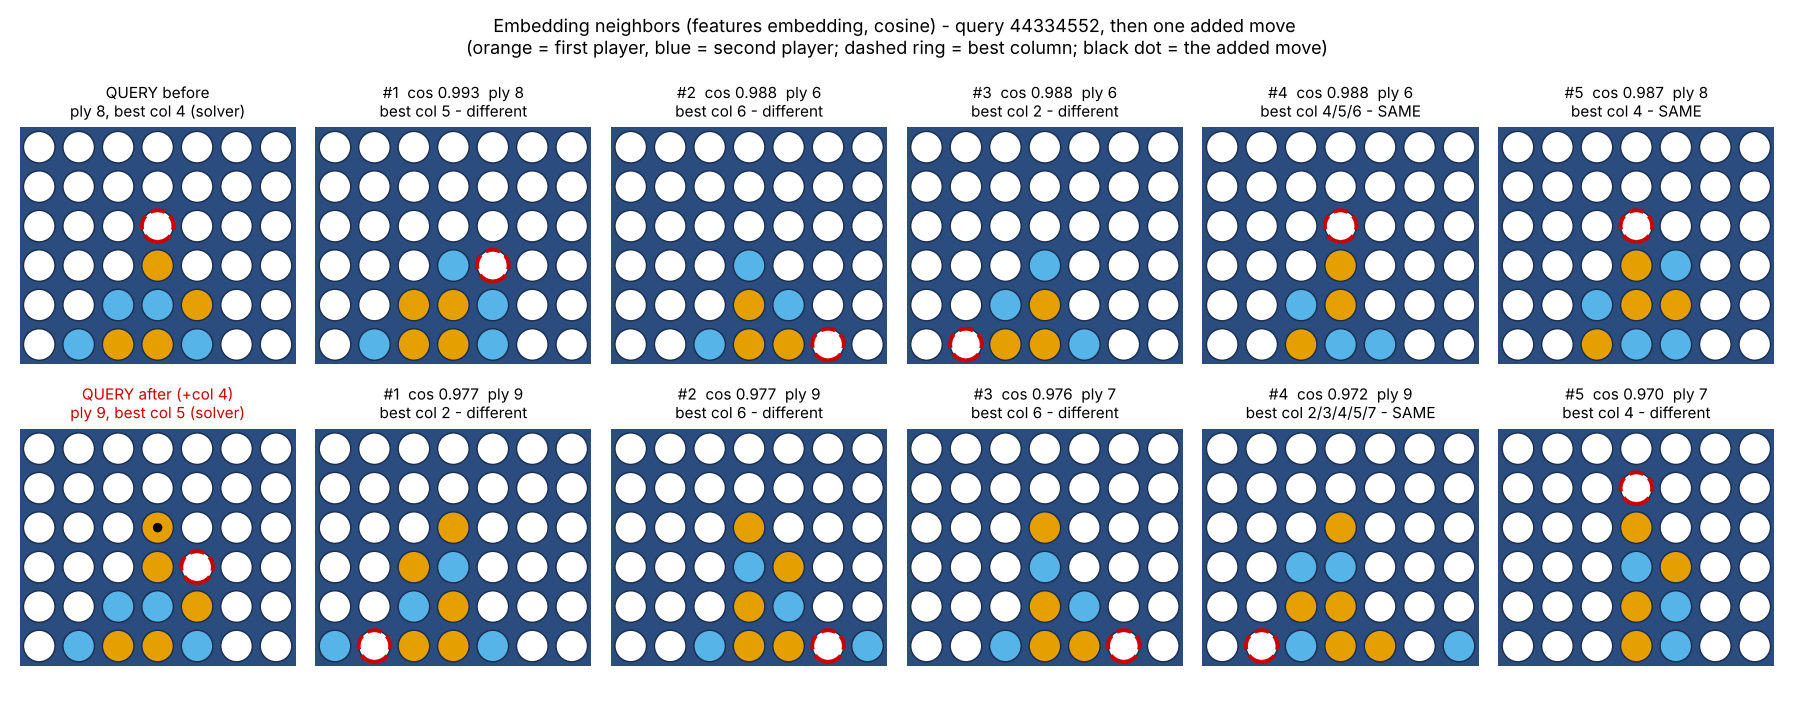

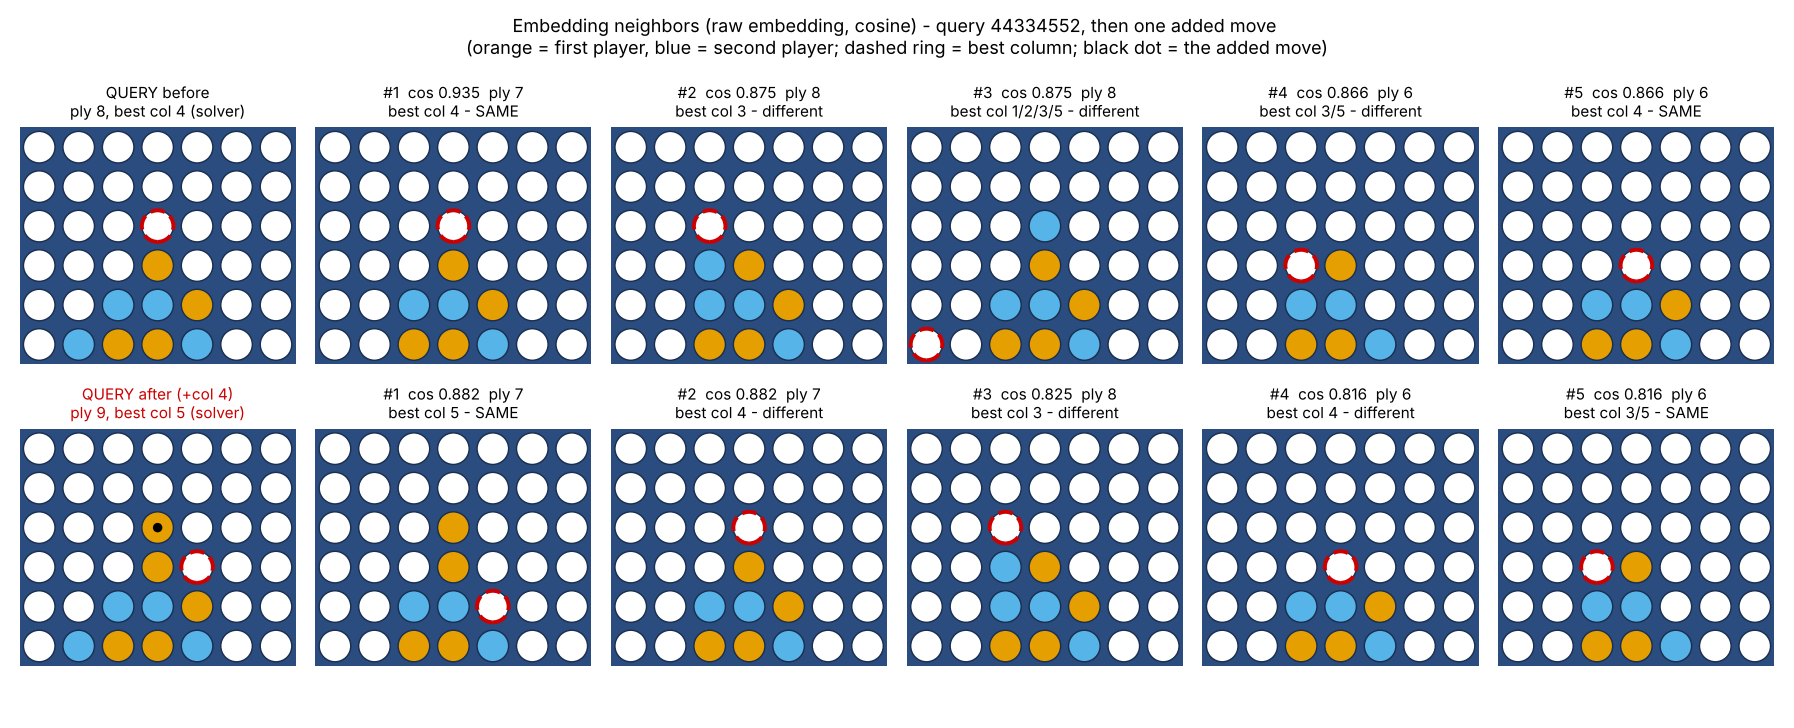

features  before           same best move in top-5: 40%
features  after (+col 4)   same best move in top-5: 20%
features  top-5 overlap before/after the change: 0 of 5
raw       before           same best move in top-5: 40%
raw       after (+col 4)   same best move in top-5: 40%
raw       top-5 overlap before/after the change: 4 of 5


,embedding,pairs,share_optimal_col_overlap,share_same_outcome,mean_abs_ply_diff
0,features,15000,0.4842,0.6410,2.28
1,raw,15000,0.4211,0.4946,6.28
2,random_same_bucket,15000,0.4013,0.4952,1.17
3,random_any,15000,0.3873,0.4855,7.84


In [12]:
display(Image(os.path.join(plots.FIGURES, "embedding_neighbors.png")))
display(Image(os.path.join(plots.FIGURES, "embedding_neighbors_raw.png")))
e = json.load(open(R("embedding_neighbors.json")))
for name, rep in e["embeddings"].items():
    for q, v in rep.items():
        if isinstance(v, dict):
            print("%-9s %-16s same best move in top-5: %.0f%%" % (name, q, 100 * v["share_same_best_move"]))
    print("%-9s top-5 overlap before/after the change: %d of 5" % (name, rep["top_k_overlap_before_after"]))
display(pd.read_csv(R("embedding_label_agreement.csv")))